In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")


In [2]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"

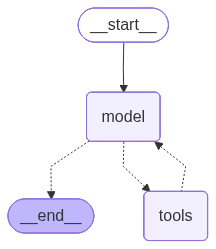

In [3]:
from langchain.agents import create_agent
agent=create_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[get_weather],
    system_prompt="You are a helpful assistant.."
)

agent

In [4]:
response=agent.invoke({"messages":[{"role":"user", "content":"What's the weather now in Bangalore?"}]})
response

{'messages': [HumanMessage(content="What's the weather now in Bangalore?", additional_kwargs={}, response_metadata={}, id='debc9f9d-139e-4f58-bac7-8265ba5bbce1'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Bangalore"}'}, '__gemini_function_call_thought_signatures__': {'a7ojzi5x': 'EtcBCtQBAQw51sc5ASjMX2GRxxBqAbcI5kde5JmunSXB6468mGTPDIKOvxxSeNakEVjBMAKkCakG42yTPsQQjk4gXzO+Kow5yCYsEIrN2tDPb6v9e8XvOZKia25J3yqLvcf8euGTFjfgnYfO0X9Q+0KCCEoXU+NnysCrN7RtW1sr09qEYw9v64OZsOeJjvgsGLzDSXHPc2pIQ6E5vbzq+GdXQzctbfjlnfwGRPMjVa3frh7XiXP64DVA2ehANv3N8GgKbSZDVYL20CkaogD5zK00yROAPFlpCtE='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f1d51-df2d-74a3-af97-fbf11500bbac-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Bangalore'}, 'id': 'a7ojzi5x', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens

In [7]:
response['messages'][-1].text()

"It's sunny in Bangalore."

In [8]:
from langchain_groq import ChatGroq
import os 

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model=ChatGroq(model="openai/gpt-oss-120b")


agent=create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a very helpful assistant."
)



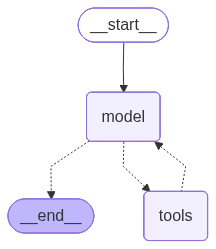

In [9]:
agent

In [10]:
response=agent.invoke({"messages":[{"role":"user", "content":"What's the weather now in Bangalore?"}]})
response

{'messages': [HumanMessage(content="What's the weather now in Bangalore?", additional_kwargs={}, response_metadata={}, id='036f7d4d-57ff-43ed-a0cf-289e35954422'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks current weather in Bangalore. Need to use function get_weather.', 'tool_calls': [{'id': 'fc_c21b6a06-d11e-46c6-8040-8e309c37ddd1', 'function': {'arguments': '{"location":"Bangalore"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 137, 'total_tokens': 181, 'completion_time': 0.091695692, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.006787825, 'prompt_tokens_details': None, 'queue_time': 0.470923925, 'total_time': 0.098483517}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bb691ea66b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1d60-61e3-7d13-ac9a-25e05

In [11]:
response['messages'][-1].text()


"It's currently sunny in Bangalore."